# EEG_00_labels_and_tasks

Questo notebook crea **etichette alternative** (cluster semantici) a partire dalle 110 parole del dataset.

Output in `data/interim/`:
- `idx2label.json`
- `word2cluster_4.json` / `labelid2cluster_4.json` — Ward gerarchico, 4 classi (automatico)
- `word2cluster_5.json` / `labelid2cluster_5.json` — Ward + KMeans split, 5 classi (automatico)
- `word2cluster_pos4.json` / `labelid2cluster_pos4.json` — **POS linguistico, 4 classi (manuale)**
- `word2cluster_sem5.json` / `labelid2cluster_sem5.json` — **Semantico-BCI, 5 classi (manuale)**
- `cluster_names_pos4.json` / `cluster_names_sem5.json` — nomi leggibili delle classi

Modello embedding: `paraphrase-multilingual-MiniLM-L12-v2` (Sentence-BERT).

Data: 2026-03-12


In [1]:
from pathlib import Path
import os, json
import numpy as np
from collections import defaultdict

# evita warning/tokenizers fork
os.environ["TOKENIZERS_PARALLELISM"] = "false"

project_root = Path("/Users/danieleuras/Documents/GitHub/miralis-hypergraph-imagined-speech")
interim_dir = project_root / "data" / "interim"
interim_dir.mkdir(parents=True, exist_ok=True)

label2idx_path = interim_dir / "label2idx.json"
assert label2idx_path.exists(), f"Missing {label2idx_path}"

with open(label2idx_path, "r", encoding="utf-8") as f:
    label2idx = json.load(f)

label2idx = {str(k): int(v) for k, v in label2idx.items()}
idx2label = {int(v): str(k) for k, v in label2idx.items()}

# lista parole in ordine di label_id
true_labels = [idx2label[i] for i in sorted(idx2label.keys())]

print("num labels:", len(true_labels))
print("first 10:", true_labels[:10])

# salva idx2label comodo
idx2label_path = interim_dir / "idx2label.json"
with open(idx2label_path, "w", encoding="utf-8") as f:
    json.dump({str(k): v for k, v in idx2label.items()}, f, ensure_ascii=False, indent=2)
print("saved:", idx2label_path)


num labels: 110
first 10: ['accendere', 'acqua', 'adesso', 'aiuto', 'amore', 'anche', 'andare', 'anno', 'ansia', 'aprire']
saved: /Users/danieleuras/Documents/GitHub/miralis-hypergraph-imagined-speech/data/interim/idx2label.json


## Install (una volta sola nell’ambiente)
Se ti mancano librerie, scommenta e runna.


In [2]:
# !pip install -q sentence-transformers scipy scikit-learn


In [3]:
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.cluster import KMeans


## 1) Embeddings semantici


In [4]:
model_name = "paraphrase-multilingual-MiniLM-L12-v2"
model = SentenceTransformer(model_name)

emb = model.encode(true_labels, normalize_embeddings=True)
emb = np.asarray(emb, dtype=np.float32)

print("emb shape:", emb.shape)


emb shape: (110, 384)


## 2) Clustering gerarchico + dendrogram (Ward)


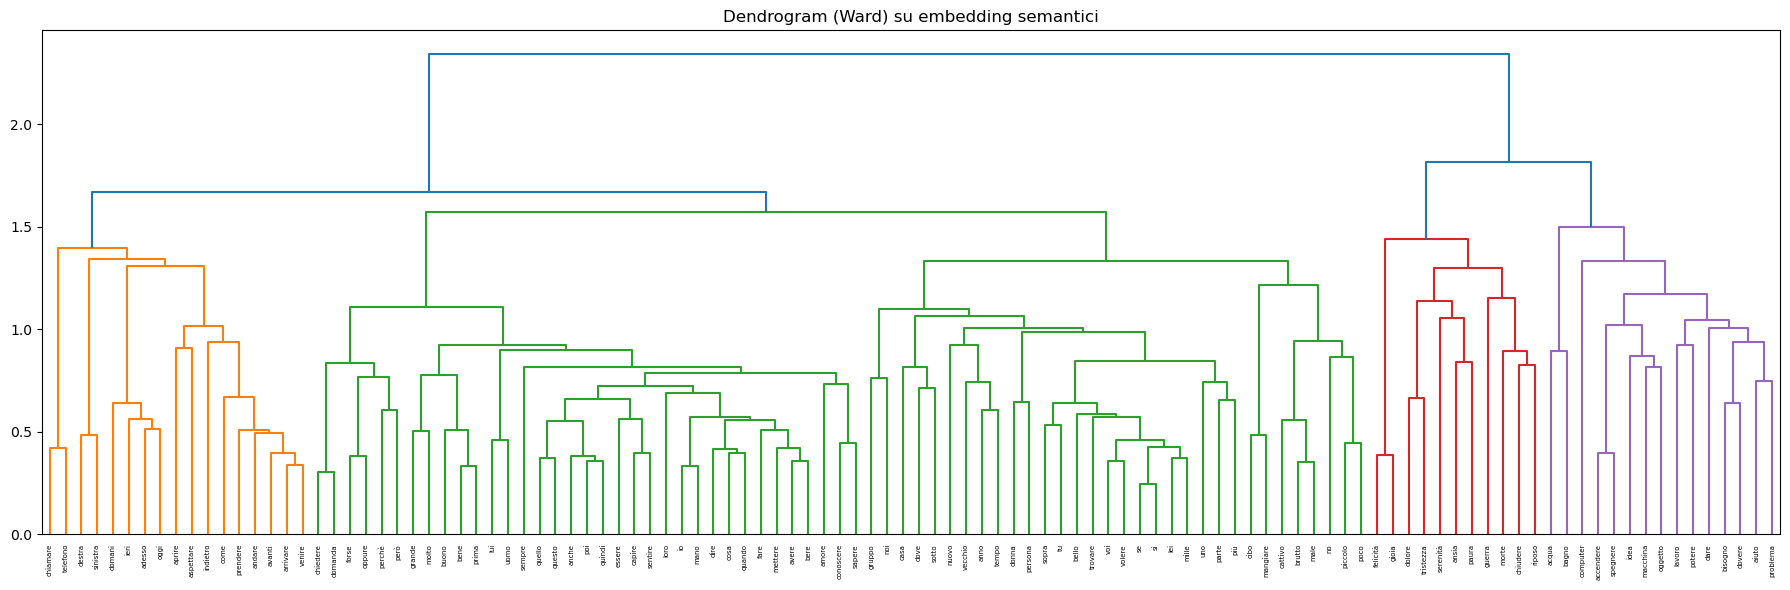

In [5]:
Z = linkage(emb, method="ward")

plt.figure(figsize=(18, 6))
dendrogram(Z, labels=true_labels, leaf_rotation=90)
plt.title("Dendrogram (Ward) su embedding semantici")
plt.tight_layout()
plt.show()


## 3) Taglio a 4 cluster + stampa stile tuo


In [6]:
cluster_ids_4 = fcluster(Z, t=4, criterion="maxclust")  # 1..4
cluster_ids_4 = cluster_ids_4 - 1                       # 0..3

cluster2words_4 = defaultdict(list)
for w, c in zip(true_labels, cluster_ids_4):
    cluster2words_4[int(c)].append(w)

print("=== CLUSTER A 4 CLASSI ===")
for c in sorted(cluster2words_4.keys()):
    print(f"\nCLUSTER {c}:")
    print(", ".join(cluster2words_4[c]))

word2cluster_4 = {w: int(c) for w, c in zip(true_labels, cluster_ids_4)}
out_word2c4 = interim_dir / "word2cluster_4.json"
with open(out_word2c4, "w", encoding="utf-8") as f:
    json.dump(word2cluster_4, f, ensure_ascii=False, indent=2)
print(f"\nSaved semantic cluster mapping to {out_word2c4}")


=== CLUSTER A 4 CLASSI ===

CLUSTER 0:
adesso, andare, aprire, arrivare, aspettare, avanti, chiamare, come, destra, domani, ieri, indietro, oggi, prendere, sinistra, telefono, venire

CLUSTER 1:
amore, anche, anno, avere, bello, bene, bere, brutto, buono, capire, casa, cattivo, chiedere, cibo, conoscere, cosa, dire, domanda, donna, dove, essere, fare, forse, grande, gruppo, io, lei, loro, lui, male, mangiare, mano, mettere, mille, molto, no, noi, nuovo, oppure, parte, perchè, persona, però, piccolo, più, poco, poi, prima, quando, quello, questo, quindi, sapere, se, sempre, sentire, si, sopra, sotto, tempo, trovare, tu, uno, uomo, vecchio, voi, volere

CLUSTER 2:
ansia, chiudere, dolore, felicità, gioia, guerra, morte, paura, riposo, serenità, tristezza

CLUSTER 3:
accendere, acqua, aiuto, bagno, bisogno, computer, dare, dovere, idea, lavoro, macchina, oggetto, potere, problema, spegnere

Saved semantic cluster mapping to /Users/danieleuras/Documents/GitHub/miralis-hypergraph-imagined-s

## 4) 5 cluster: split SOLO del cluster più grande in 2 sottocluster (k=2)


In [7]:
# trova cluster più grande
sizes = {c: len(ws) for c, ws in cluster2words_4.items()}
big_c = max(sizes, key=sizes.get)
print("largest cluster (from 4):", big_c, "size:", sizes[big_c])

idx_big = [i for i, c in enumerate(cluster_ids_4) if int(c) == int(big_c)]
emb_big = emb[idx_big]

km_sub = KMeans(n_clusters=2, random_state=42, n_init=10)
sub_ids = km_sub.fit_predict(emb_big)  # 0/1

new_cluster_ids = np.array(cluster_ids_4, dtype=int)  # start from 0..3
new_id = 4

for j, i_word in enumerate(idx_big):
    if int(sub_ids[j]) == 0:
        new_cluster_ids[i_word] = int(big_c)
    else:
        new_cluster_ids[i_word] = new_id

# ricompatta per avere 0..4 sempre
uniq = sorted(np.unique(new_cluster_ids).tolist())
remap = {old: new for new, old in enumerate(uniq)}
cluster_ids_5 = np.array([remap[int(c)] for c in new_cluster_ids], dtype=int)

cluster2words_5 = defaultdict(list)
for w, c in zip(true_labels, cluster_ids_5):
    cluster2words_5[int(c)].append(w)

print("\n=== CLUSTER FINALI A 5 CLASSI ===")
for c in sorted(cluster2words_5.keys()):
    print(f"\nCLUSTER {c}:")
    print(", ".join(cluster2words_5[c]))

word2cluster_5 = {w: int(c) for w, c in zip(true_labels, cluster_ids_5)}
out_word2c5 = interim_dir / "word2cluster_5.json"
with open(out_word2c5, "w", encoding="utf-8") as f:
    json.dump(word2cluster_5, f, ensure_ascii=False, indent=2)
print(f"\nSaved semantic cluster mapping to {out_word2c5}")


largest cluster (from 4): 1 size: 67

=== CLUSTER FINALI A 5 CLASSI ===

CLUSTER 0:
adesso, andare, aprire, arrivare, aspettare, avanti, chiamare, come, destra, domani, ieri, indietro, oggi, prendere, sinistra, telefono, venire

CLUSTER 1:
anno, bello, brutto, casa, cattivo, cibo, donna, dove, fare, grande, gruppo, lei, male, mangiare, mille, no, nuovo, parte, persona, piccolo, più, poco, se, sopra, sotto, tempo, trovare, uno, uomo, vecchio, voi

CLUSTER 2:
ansia, chiudere, dolore, felicità, gioia, guerra, morte, paura, riposo, serenità, tristezza

CLUSTER 3:
accendere, acqua, aiuto, bagno, bisogno, computer, dare, dovere, idea, lavoro, macchina, oggetto, potere, problema, spegnere

CLUSTER 4:
amore, anche, avere, bene, bere, buono, capire, chiedere, conoscere, cosa, dire, domanda, essere, forse, io, loro, lui, mano, mettere, molto, noi, oppure, perchè, però, poi, prima, quando, quello, questo, quindi, sapere, sempre, sentire, si, tu, volere

Saved semantic cluster mapping to /Users/da

## 5) label_id -> cluster_id (per training)


In [8]:
labelid2cluster_4 = {int(label2idx[w]): int(word2cluster_4[w]) for w in true_labels}
labelid2cluster_5 = {int(label2idx[w]): int(word2cluster_5[w]) for w in true_labels}

out_l2c4 = interim_dir / "labelid2cluster_4.json"
out_l2c5 = interim_dir / "labelid2cluster_5.json"

with open(out_l2c4, "w", encoding="utf-8") as f:
    json.dump({str(k): v for k, v in labelid2cluster_4.items()}, f, ensure_ascii=False, indent=2)
with open(out_l2c5, "w", encoding="utf-8") as f:
    json.dump({str(k): v for k, v in labelid2cluster_5.items()}, f, ensure_ascii=False, indent=2)

print("saved:", out_l2c4)
print("saved:", out_l2c5)

print("\nEsempio mapping (prime 10 parole):")
for w in true_labels[:10]:
    print(w, "->", word2cluster_5[w])


saved: /Users/danieleuras/Documents/GitHub/miralis-hypergraph-imagined-speech/data/interim/labelid2cluster_4.json
saved: /Users/danieleuras/Documents/GitHub/miralis-hypergraph-imagined-speech/data/interim/labelid2cluster_5.json

Esempio mapping (prime 10 parole):
accendere -> 3
acqua -> 3
adesso -> 0
aiuto -> 3
amore -> 4
anche -> 4
andare -> 0
anno -> 1
ansia -> 2
aprire -> 0


## 6) Helper: rimappa y (label_id) in cluster_id


In [9]:
def remap_y_to_clusters(y, labelid2cluster):
    y = np.asarray(y, dtype=int)
    return np.array([labelid2cluster[int(v)] for v in y], dtype=int)

# esempio:
# with open(interim_dir/'labelid2cluster_5.json','r') as f: m = {int(k):int(v) for k,v in json.load(f).items()}
# y_cluster5 = remap_y_to_clusters(y_epochs, m)


---

## 7) Analisi del numero ottimale di cluster (silhouette + elbow)

Il Ward gerarchico con `fcluster(t=4)` sceglie k arbitrariamente.  
Qui valutiamo empiricamente su KMeans quale k è più supportato dagli embedding.

**Nota**: un silhouette alto indica cluster compatti e separati nello spazio embedding — non garantisce interpretabilità semantica, ma orienta la scelta.


In [ ]:
import pandas as pd
from sklearn.metrics import silhouette_score, davies_bouldin_score

k_range = list(range(2, 11))
metrics = []
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=30)
    labels = km.fit_predict(emb)
    metrics.append({
        "k": k,
        "silhouette": silhouette_score(emb, labels),
        "davies_bouldin": davies_bouldin_score(emb, labels),
        "inertia": km.inertia_
    })

df_m = pd.DataFrame(metrics)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
df_m.plot(x="k", y="silhouette", ax=axes[0], marker="o", legend=False)
axes[0].set_title("Silhouette Score (↑ migliore)"); axes[0].set_xlabel("k")

df_m.plot(x="k", y="davies_bouldin", ax=axes[1], marker="o", legend=False, color="orange")
axes[1].set_title("Davies-Bouldin (↓ migliore)"); axes[1].set_xlabel("k")

df_m.plot(x="k", y="inertia", ax=axes[2], marker="o", legend=False, color="green")
axes[2].set_title("Inertia / Elbow"); axes[2].set_xlabel("k")

plt.suptitle("Selezione ottimale del numero di cluster (KMeans su embedding SBERT)", fontsize=12)
plt.tight_layout()
plt.show()

best_k = int(df_m.loc[df_m["silhouette"].idxmax(), "k"])
print(f"k ottimale per silhouette: {best_k}")
print(df_m.to_string(index=False))


---

## 8) Schema POS — 4 classi grammaticali (manuale)

Classificazione basata sulla **parte del discorso** (Part-of-Speech) italiana.  
È lo schema più rigido linguisticamente: ogni parola appartiene a una sola categoria grammaticale.

| Classe | Descrizione | Esempi |
|--------|-------------|--------|
| **VERBI** | Verbi all'infinito presente | andare, fare, sentire |
| **SOSTANTIVI** | Sostantivi concreti e astratti | casa, dolore, idea |
| **MODIFICATORI** | Aggettivi e avverbi con contenuto lessicale | bello, sempre, piccolo |
| **GRAMMATICALI** | Pronomi, congiunzioni, particelle | io, perchè, oppure |

> Questa classificazione è **indipendente dagli embedding**: non usa affatto il modello SBERT.


In [ ]:
# Schema POS: 4 classi grammaticali italiane
manual_pos = {
    "VERBI": [
        # tutti verbi all'infinito presente — azioni fisiche, cognitive, modali
        "accendere", "andare", "aprire", "arrivare", "aspettare", "avere",
        "bere", "capire", "chiamare", "chiedere", "chiudere", "conoscere",
        "dare", "dire", "dovere", "essere", "fare", "mangiare", "mettere",
        "potere", "prendere", "sapere", "sentire", "spegnere", "trovare",
        "venire", "volere"
    ],
    "SOSTANTIVI": [
        # nomi concreti e astratti — oggetti, luoghi, stati, concetti
        "acqua", "aiuto", "amore", "anno", "ansia", "bagno", "bisogno",
        "casa", "cibo", "computer", "dolore", "domanda", "donna", "felicità",
        "gioia", "gruppo", "guerra", "idea", "lavoro", "macchina", "mano",
        "mille", "morte", "oggetto", "paura", "parte", "persona", "problema",
        "riposo", "serenità", "telefono", "tempo", "tristezza", "uomo"
    ],
    "MODIFICATORI": [
        # aggettivi e avverbi con significato lessicale autonomo
        "adesso", "avanti", "bello", "bene", "brutto", "buono", "cattivo",
        "destra", "domani", "grande", "ieri", "indietro", "male", "molto",
        "nuovo", "oggi", "piccolo", "più", "poco", "poi", "prima",
        "sempre", "sinistra", "sopra", "sotto", "vecchio"
    ],
    "GRAMMATICALI": [
        # pronomi personali, congiunzioni, particelle, numerali, deittici
        "anche", "come", "cosa", "dove", "forse", "io", "lei", "loro",
        "lui", "no", "noi", "oppure", "perchè", "però", "quando",
        "quello", "questo", "quindi", "se", "si", "tu", "uno", "voi"
    ]
}

# --- validazione: ogni parola del dataset deve apparire esattamente una volta ---
all_assigned_pos = [w for ws in manual_pos.values() for w in ws]
missing_pos  = set(true_labels) - set(all_assigned_pos)
extra_pos    = set(all_assigned_pos) - set(true_labels)
dupl_pos     = {w for w in all_assigned_pos if all_assigned_pos.count(w) > 1}

print(f"Dataset: {len(true_labels)} parole | Assegnate: {len(all_assigned_pos)}")
print(f"Mancanti dal dataset: {missing_pos or '—'}")
print(f"Parole extra (non nel dataset): {extra_pos or '—'}")
print(f"Duplicati: {dupl_pos or '—'}")

print("\n=== SCHEMA POS — 4 CLASSI ===")
for cat, words in manual_pos.items():
    print(f"\n{cat} ({len(words)}):")
    print(", ".join(sorted(words)))


In [ ]:
# Costruzione mapping e salvataggio schema POS-4
cat_names_pos4 = list(manual_pos.keys())

word2cluster_pos4 = {}
for cat_id, (cat_name, words) in enumerate(manual_pos.items()):
    for w in words:
        if w in set(true_labels):
            word2cluster_pos4[w] = cat_id

# catch-all per eventuali parole non coperte dallo schema
for w in true_labels:
    if w not in word2cluster_pos4:
        print(f"ATTENZIONE: '{w}' non assegnata → assegnata a GRAMMATICALI (3)")
        word2cluster_pos4[w] = 3

labelid2cluster_pos4 = {int(label2idx[w]): int(word2cluster_pos4[w]) for w in true_labels}

out_pos4      = interim_dir / "word2cluster_pos4.json"
out_pos4_lid  = interim_dir / "labelid2cluster_pos4.json"
out_pos4_names = interim_dir / "cluster_names_pos4.json"

with open(out_pos4, "w", encoding="utf-8") as f:
    json.dump(word2cluster_pos4, f, ensure_ascii=False, indent=2)
with open(out_pos4_lid, "w", encoding="utf-8") as f:
    json.dump({str(k): v for k, v in labelid2cluster_pos4.items()}, f, ensure_ascii=False, indent=2)
with open(out_pos4_names, "w", encoding="utf-8") as f:
    json.dump({str(i): name for i, name in enumerate(cat_names_pos4)}, f, ensure_ascii=False, indent=2)

print(f"Saved: {out_pos4}")
print(f"Saved: {out_pos4_lid}")
print(f"Saved: {out_pos4_names}")
print("\nDistribuzione classi POS-4:")
for cat_id, cat_name in enumerate(cat_names_pos4):
    count = sum(1 for v in word2cluster_pos4.values() if v == cat_id)
    print(f"  {cat_id} — {cat_name:15s}: {count:3d} parole  {'█' * count}")


---

## 9) Schema Semantico-BCI — 5 classi (manuale)

Classificazione basata su **categorie semantiche rilevanti per l'EEG e il BCI**.  
Ogni classe è associata a un substrato neurale diverso, il che motiva la scelta per il decoding.

| Classe | Substrato neurale atteso | Descrizione |
|--------|--------------------------|-------------|
| **AZIONI** | Corteccia motoria/premotoria (imagery motoria) | Tutti i verbi all'infinito |
| **EMOZIONI_VALENZA** | Sistema limbico, amigdala, corteccia orbito-frontale | Emozioni + aggettivi valutativi |
| **OGGETTI_PERSONE** | Corteccia temporale inferiore (riconoscimento oggetti) | Sostantivi concreti, fisici |
| **CONCETTI_ASTRATTI** | Corteccia prefrontale, temporale superiore | Sostantivi astratti, situazioni |
| **PAROLE_FUNZIONE** | Aree linguistiche (Broca/Wernicke), rete del default mode | Pronomi, congiunzioni, deittici, quantificatori |

> **Motivazione**: rispetto al Ward gerarchico, questa classificazione evita cluster incoerenti  
> (es. il vecchio CLUSTER 1 con 67 parole eterogenee) e permette interpretazioni neurologiche dirette.


In [ ]:
# Schema Semantico-BCI: 5 classi neuroscientificamente motivate
manual_sem5 = {
    "AZIONI": [
        # tutti i verbi all'infinito (imagery motoria, action planning)
        "accendere", "andare", "aprire", "arrivare", "aspettare", "avere",
        "bere", "capire", "chiamare", "chiedere", "chiudere", "conoscere",
        "dare", "dire", "dovere", "essere", "fare", "mangiare", "mettere",
        "potere", "prendere", "sapere", "sentire", "spegnere", "trovare",
        "venire", "volere"
    ],
    "EMOZIONI_VALENZA": [
        # stati emotivi e aggettivi con valenza affettiva forte (sistema limbico)
        "amore", "ansia", "bello", "bene", "brutto", "buono", "cattivo",
        "dolore", "felicità", "gioia", "guerra", "male", "morte",
        "paura", "riposo", "serenità", "tristezza"
    ],
    "OGGETTI_PERSONE": [
        # referenti concreti fisicamente immaginabili: oggetti, luoghi, persone
        "acqua", "aiuto", "bagno", "casa", "cibo", "computer", "donna",
        "gruppo", "macchina", "mano", "oggetto", "persona", "telefono", "uomo"
    ],
    "CONCETTI_ASTRATTI": [
        # sostantivi astratti: concetti, situazioni, relazioni senza referente fisico
        "anno", "bisogno", "domanda", "idea", "lavoro", "mille",
        "parte", "problema", "tempo"
    ],
    "PAROLE_FUNZIONE": [
        # pronomi personali, congiunzioni, avverbi, deittici spaziali/temporali, quantificatori
        "adesso", "anche", "avanti", "come", "cosa", "destra", "domani",
        "dove", "forse", "grande", "ieri", "indietro", "io", "lei", "loro",
        "lui", "molto", "noi", "no", "nuovo", "oggi", "oppure", "perchè",
        "però", "piccolo", "più", "poco", "poi", "prima", "quando",
        "quello", "questo", "quindi", "se", "sempre", "sinistra", "si",
        "sopra", "sotto", "tu", "uno", "vecchio", "voi"
    ]
}

# --- validazione ---
all_assigned_sem = [w for ws in manual_sem5.values() for w in ws]
missing_sem  = set(true_labels) - set(all_assigned_sem)
extra_sem    = set(all_assigned_sem) - set(true_labels)
dupl_sem     = {w for w in all_assigned_sem if all_assigned_sem.count(w) > 1}

print(f"Dataset: {len(true_labels)} parole | Assegnate: {len(all_assigned_sem)}")
print(f"Mancanti: {missing_sem or '—'}")
print(f"Extra: {extra_sem or '—'}")
print(f"Duplicati: {dupl_sem or '—'}")

print("\n=== SCHEMA SEMANTICO-BCI — 5 CLASSI ===")
for cat, words in manual_sem5.items():
    print(f"\n{cat} ({len(words)}):")
    print(", ".join(sorted(words)))


In [ ]:
# Costruzione mapping e salvataggio schema Semantico-BCI 5
cat_names_sem5 = list(manual_sem5.keys())

word2cluster_sem5 = {}
for cat_id, (cat_name, words) in enumerate(manual_sem5.items()):
    for w in words:
        if w in set(true_labels):
            word2cluster_sem5[w] = cat_id

# catch-all
for w in true_labels:
    if w not in word2cluster_sem5:
        print(f"ATTENZIONE: '{w}' non assegnata → PAROLE_FUNZIONE (4)")
        word2cluster_sem5[w] = 4

labelid2cluster_sem5 = {int(label2idx[w]): int(word2cluster_sem5[w]) for w in true_labels}

out_sem5       = interim_dir / "word2cluster_sem5.json"
out_sem5_lid   = interim_dir / "labelid2cluster_sem5.json"
out_sem5_names = interim_dir / "cluster_names_sem5.json"

with open(out_sem5, "w", encoding="utf-8") as f:
    json.dump(word2cluster_sem5, f, ensure_ascii=False, indent=2)
with open(out_sem5_lid, "w", encoding="utf-8") as f:
    json.dump({str(k): v for k, v in labelid2cluster_sem5.items()}, f, ensure_ascii=False, indent=2)
with open(out_sem5_names, "w", encoding="utf-8") as f:
    json.dump({str(i): name for i, name in enumerate(cat_names_sem5)}, f, ensure_ascii=False, indent=2)

print(f"Saved: {out_sem5}")
print(f"Saved: {out_sem5_lid}")
print(f"Saved: {out_sem5_names}")
print("\nDistribuzione classi Semantico-BCI-5:")
for cat_id, cat_name in enumerate(cat_names_sem5):
    count = sum(1 for v in word2cluster_sem5.values() if v == cat_id)
    print(f"  {cat_id} — {cat_name:22s}: {count:3d} parole  {'█' * count}")


---

## 10) Visualizzazione comparata PCA 2D — tutti gli schemi


In [ ]:
from sklearn.decomposition import PCA
import matplotlib.patches as mpatches

pca = PCA(n_components=2)
coords = pca.fit_transform(emb)
var1, var2 = pca.explained_variance_ratio_

# ward cluster labels come array
labels_ward4 = np.array([word2cluster_4[w] for w in true_labels])
labels_ward5 = np.array([word2cluster_5[w] for w in true_labels])
labels_pos4  = np.array([word2cluster_pos4[w] for w in true_labels])
labels_sem5  = np.array([word2cluster_sem5[w] for w in true_labels])

# nomi cluster Ward (retroattivi, basati sull'osservazione)
ward4_names = ["MOVIMENTO", "MISTO_GRANDE", "EMOZIONI", "AZIONI_OGGETTI"]
ward5_names = ["MOVIMENTO", "DESCRITTIVO", "EMOZIONI", "AZIONI_OGGETTI", "COGNITIVO"]

schemes = [
    ("Ward-4 (automatico)",        labels_ward4, ward4_names),
    ("Ward-5 (automatico)",        labels_ward5, ward5_names),
    ("POS-4 (manuale gramm.)",     labels_pos4,  cat_names_pos4),
    ("Semantico-BCI-5 (manuale)",  labels_sem5,  cat_names_sem5),
]

fig, axes = plt.subplots(2, 2, figsize=(20, 16))
cmap = plt.get_cmap("tab10")

# indici parole da annotare (ogni ~6 per leggibilità)
annotate_idx = set(range(0, len(true_labels), 6))

for ax, (title, labels, cat_names) in zip(axes.flatten(), schemes):
    n_cls = len(set(labels))
    patches = []
    for c in sorted(set(labels)):
        mask = labels == c
        cat_label = cat_names[c] if c < len(cat_names) else f"C{c}"
        color = cmap(c / 10)
        ax.scatter(coords[mask, 0], coords[mask, 1],
                   color=color, alpha=0.75, s=55, zorder=2)
        patches.append(mpatches.Patch(color=color,
                        label=f"{c}: {cat_label} (n={mask.sum()})"))

    # annotazioni parole
    for i, (w, x, y) in enumerate(zip(true_labels, coords[:, 0], coords[:, 1])):
        lbl = labels[i]
        if i in annotate_idx:
            ax.annotate(w, (x, y), fontsize=7, alpha=0.8,
                        color=cmap(lbl / 10),
                        xytext=(3, 3), textcoords="offset points")

    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel(f"PC1 ({var1:.1%} var.)")
    ax.set_ylabel(f"PC2 ({var2:.1%} var.)")
    ax.legend(handles=patches, fontsize=7.5, loc="upper right",
              framealpha=0.8, title="Classi")
    ax.grid(True, alpha=0.2)

plt.suptitle("Proiezione PCA degli embedding SBERT — confronto schemi di clustering\n"
             f"(PC1+PC2 spiegano {var1+var2:.1%} della varianza)",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


In [ ]:
# Confronto silhouette score tra tutti gli schemi
print("Confronto qualità cluster (silhouette su embedding SBERT):")
print(f"{'Schema':<38} {'k':>4} {'Silhouette':>12}")
print("─" * 57)

for title, labels, _ in schemes:
    arr = np.array(labels)
    if len(set(arr)) > 1:
        sil = silhouette_score(emb, arr)
        print(f"{title:<38} {len(set(arr)):>4} {sil:>12.4f}")

print()
print("Note:")
print("  • Silhouette misura quanto ogni punto è simile al proprio cluster")
print("    rispetto agli altri (scala -1..+1, >0.1 è già ragionevole per testo)")
print("  • Gli schemi manuali possono avere silhouette più bassa degli automatici")
print("    ma sono semanticamente e neuroscientificamente più interpretabili.")
print("  • Per il training EEG, la coerenza semantica è più importante della")
print("    coerenza geometrica negli embedding linguistici.")

print("\n─── File salvati ───")
for f in sorted(interim_dir.glob("*.json")):
    print(f"  {f.name}")
